In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [36]:
df = pd.read_csv("F:\Datasets and ML\datasets\winequality-red.csv",usecols=['density','fixed acidity', 'alcohol'])

In [37]:
df.head()

,fixed acidity,density,alcohol
0,7.4,0.9978,9.4
1,7.8,0.9968,9.8
2,7.8,0.9970,9.8
3,11.2,0.9980,9.8
4,7.4,0.9978,9.4


In [38]:
df['density'] = np.multiply(df['density'],1000)

In [39]:
df.head()

,fixed acidity,density,alcohol
0,7.4,997.8,9.4
1,7.8,996.8,9.8
2,7.8,997.0,9.8
3,11.2,998.0,9.8
4,7.4,997.8,9.4


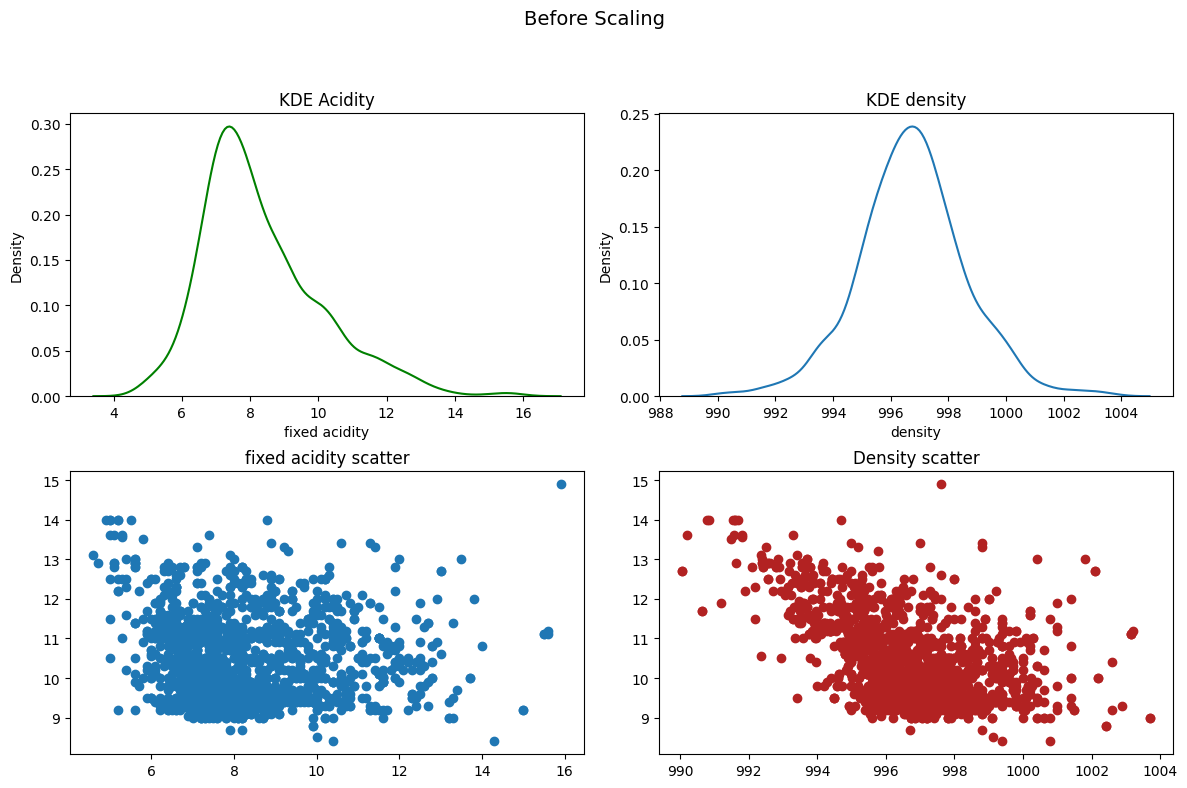

In [40]:
fig, ax= plt.subplots(ncols=2,nrows=2, figsize=(12,8))

ax[0][0].set_title('KDE Acidity')
sns.kdeplot(data = df, x = 'fixed acidity',ax = ax[0][0], color = 'g')


ax[0][1].set_title('KDE density')
sns.kdeplot(data = df,x= 'density',ax = ax[0][1])

ax[1][0].set_title('fixed acidity scatter')
ax[1][0].scatter(df['fixed acidity'], df['alcohol'])

ax[1][1].set_title('Density scatter')
ax[1][1].scatter(df['density'], df['alcohol'],  color='firebrick' )
fig.suptitle('Before Scaling', fontsize=14)
fig.tight_layout()
fig.subplots_adjust(top=0.85)

In [41]:
type(ax)

numpy.ndarray

In [42]:
from sklearn.preprocessing import MinMaxScaler

In [43]:
scaler = MinMaxScaler()

In [44]:
scaler.fit(df)

,feature_range,"(0, ...)"
,copy,True
,clip,False


In [45]:
df_scaled = pd.DataFrame(scaler.transform(df), columns = df.columns)

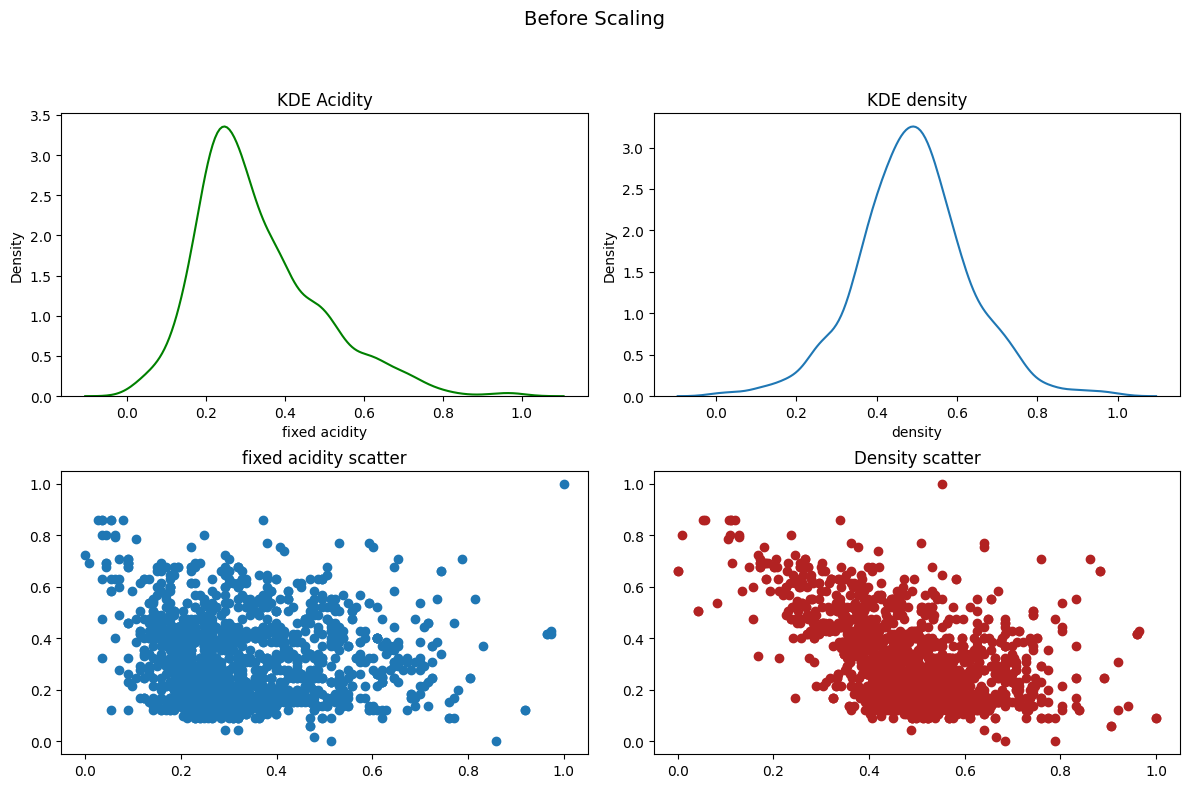

In [46]:
fig, ax= plt.subplots(ncols=2,nrows=2, figsize=(12,8))

ax[0][0].set_title('KDE Acidity')
sns.kdeplot(data = df_scaled, x = 'fixed acidity',ax = ax[0][0], color = 'g')


ax[0][1].set_title('KDE density')
sns.kdeplot(data = df_scaled,x= 'density',ax = ax[0][1])

ax[1][0].set_title('fixed acidity scatter')
ax[1][0].scatter(df_scaled['fixed acidity'], df_scaled['alcohol'])

ax[1][1].set_title('Density scatter')
ax[1][1].scatter(df_scaled['density'], df_scaled['alcohol'],  color='firebrick' )
fig.suptitle('Before Scaling', fontsize=14)
fig.tight_layout()
fig.subplots_adjust(top=0.85)

In [52]:
np.round(df.describe(),1)

,fixed acidity,density,alcohol
count,1599.0,1599.0,1599.0
mean,8.3,996.7,10.4
std,1.7,1.9,1.1
min,4.6,990.1,8.4
25%,7.1,995.6,9.5
50%,7.9,996.8,10.2
75%,9.2,997.8,11.1
max,15.9,1003.7,14.9


In [54]:
np.round(df_scaled.describe(),1)

,fixed acidity,density,alcohol
count,1599.0,1599.0,1599.0
mean,0.3,0.5,0.3
std,0.2,0.1,0.2
min,0.0,0.0,0.0
25%,0.2,0.4,0.2
50%,0.3,0.5,0.3
75%,0.4,0.6,0.4
max,1.0,1.0,1.0


<Axes: title={'center': 'Density & Fixed Acidity After Normalization'}, xlabel='density', ylabel='Density'>

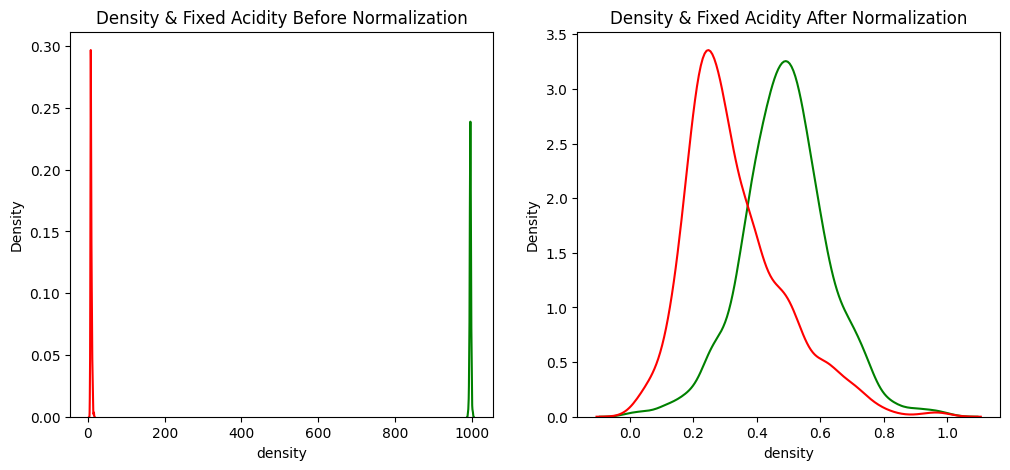

In [60]:
fig, ax = plt.subplots(ncols=2,figsize=(12,5))

ax[0].set_title('Density & Fixed Acidity Before Normalization')
sns.kdeplot(df['density'], color = 'g',ax = ax[0])
sns.kdeplot(df['fixed acidity'], color = 'r', ax = ax[0])

ax[1].set_title('Density & Fixed Acidity After Normalization')
sns.kdeplot(df_scaled['density'], color = 'g',ax = ax[1])
sns.kdeplot(df_scaled['fixed acidity'], color = 'r', ax = ax[1])

In [61]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# 1. Create data: Normal people (50k) vs. an extreme outlier (1 Million)
data = {'Salary': [48000, 50000, 52000, 49000, 51000, 1000000]} 
df = pd.DataFrame(data)

# 2. Scale it
scaler = StandardScaler()
df['Scaled'] = scaler.fit_transform(df[['Salary']])

# 3. View the results
print(df)



    Salary    Scaled
0    48000 -0.452860
1    50000 -0.447211
2    52000 -0.441562
3    49000 -0.450035
4    51000 -0.444386
5  1000000  2.236053


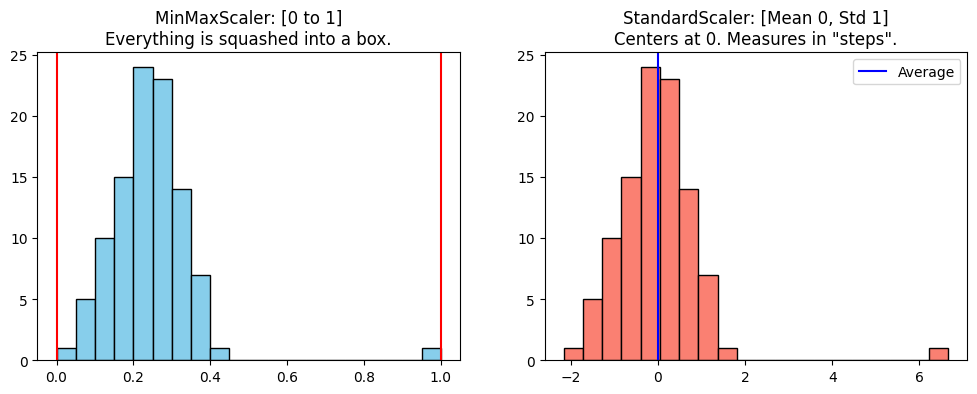

       Height  MinMax  Standard
count  101.00  101.00    101.00
mean   169.76    0.24      0.00
std     12.11    0.11      1.00
min    143.80    0.00     -2.15
25%    163.99    0.19     -0.48
50%    168.84    0.24     -0.08
75%    174.97    0.29      0.43
max    250.00    1.00      6.66


In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# 1. Create Example Data: Heights of 100 people (Avg 170cm) + 1 Giant (250cm)
np.random.seed(42)
heights = np.append(np.random.normal(170, 10, 100), [250])
df = pd.DataFrame({'Height': heights})

# 2. Apply Scalers
df['MinMax'] = MinMaxScaler().fit_transform(df[['Height']])
df['Standard'] = StandardScaler().fit_transform(df[['Height']])

# 3. Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# MinMaxScaler Graph
ax1.hist(df['MinMax'], bins=20, color='skyblue', edgecolor='black')
ax1.set_title('MinMaxScaler: [0 to 1]\nEverything is squashed into a box.')
ax1.axvline(0, color='red'); ax1.axvline(1, color='red')

# StandardScaler Graph
ax2.hist(df['Standard'], bins=20, color='salmon', edgecolor='black')
ax2.set_title('StandardScaler: [Mean 0, Std 1]\nCenters at 0. Measures in "steps".')
ax2.axvline(0, color='blue', label='Average')
ax2.legend()

plt.show()

print(df.describe().round(2))
